In [1]:
from eregion.tasks import ImageCreator, AssembleFocalPlane
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
from eregion.tasks.calibration import MasterBias, CalibrationResult
from eregion.tasks.preprocessing import BiasSubtraction, ScanSubtraction, SigmaClipMasking

import numpy as np
import matplotlib.pyplot as plt
import os
import glob2
from copy import deepcopy
import importlib

# Example: DEIMOS science focal plane characterization

In [2]:
basepath = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI'
runid = '20260718*'
rawpath = glob2.glob(os.path.join(basepath, runid))[0]
outpath = rawpath.replace('/DTU_dettest/','/DTU_detreduce/')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### Calproc

In [3]:
# Load bias images
creator = ImageCreator(detector_config = '../eregion/configs/detectors/deimos_sci.yaml')
res = creator.run(input_source = os.path.join(rawpath,'*bias*.fits'),
                  identifier_func = guess_image_type_from_filename_DEIMOS,
                  fileloader_func = load_image_fits_DEIMOS,
                  data_on_demand = True)

# make master bias
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(bias_images=res.data('type == "bias"'))


2026-07-24 20:58:29,913 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 20:58:29,914 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718-001407/*bias*.fits is a glob pattern
2026-07-24 20:58:37,804 - MasterBias - INFO - Setting method 'median' for task MasterBias.


In [4]:
# cleanup memory
del res
# save master bias result obj
mb_res.save(outpath)

In [5]:
# load master bias result obj
mb_res = CalibrationResult.load(outpath)
mb_res.master_bias

,type,exptime,seqnum,obstime,det_id,filename,object
0,master_bias,0.0,0,2026-07-18T001412.976,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e34680>
1,master_bias,0.0,0,2026-07-18T001412.976,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e347a0>
2,master_bias,0.0,0,2026-07-18T001412.976,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e348c0>
3,master_bias,0.0,0,2026-07-18T001412.976,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e349e0>
4,master_bias,0.0,0,2026-07-18T001412.976,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e34b00>
5,master_bias,0.0,0,2026-07-18T001412.976,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e34c20>
6,master_bias,0.0,0,2026-07-18T001412.976,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e34d40>
7,master_bias,0.0,0,2026-07-18T001412.976,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117e34e60>


Make focal plane image. `AssembleFocalPlane` task can take ImageBundle and group them into sets of focal plane images based on the list of columns that uniquely identify an exposure.

In [14]:
def plot_focal_plane(bundle, grouping_columns=['type', 'exptime', 'seqnum'], how_many=1, zscale=False, **imshow_kwargs):
    fp_task = AssembleFocalPlane(num_detectors=8)
    fp_res = fp_task.run(from_images=bundle, grouping_columns=grouping_columns)
    for i in range(how_many):
        img = fp_res.data[i]
        if zscale:
            vmin, vmax = np.percentile(img.data.values, [5, 95])
        else:
            vmin, vmax = None, None
        img.show(cmap='gray', show_det_id=True, vmin=vmin, vmax=vmax, **imshow_kwargs)
    return fp_res.data

,object,type,exptime,seqnum,obstime
0,<datamodels.focalplaneimage.FocalPlaneImage ob...,master_bias,0.0,0,2026-07-18T001412.976


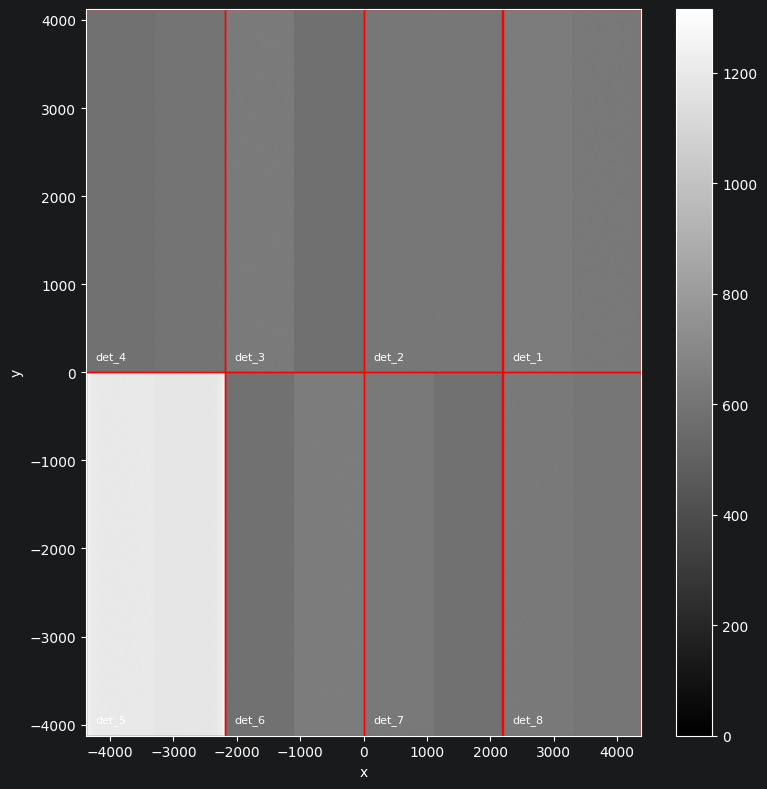

In [7]:
plot_focal_plane(mb_res.master_bias)

### Preproc

Sanity checks for each step

In [8]:
def quick_plot(img):
    vmin, vmax = np.percentile(img.data.values, [5, 95])
    img.show(cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

2026-07-24 20:58:53,465 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


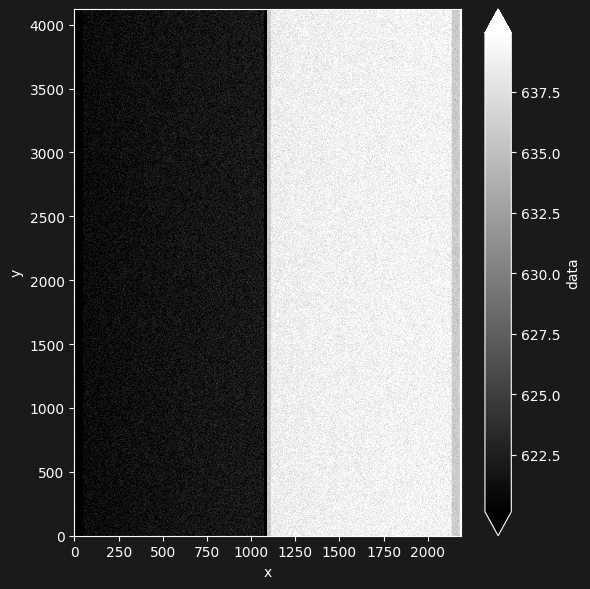

In [9]:
# plot master bias
quick_plot(mb_res.master_bias[0])

In [10]:
## Loadig first pair at exptime 0
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)

flpair = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True)
flpair.data

2026-07-24 20:58:54,144 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 20:58:54,144 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 20:58:54,145 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits is a glob pattern
2026-07-24 20:58:54,145 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits is a glob pattern


,type,exptime,seqnum,obstime,det_id,filename,object
0,flat,0.032,0,2026-07-18T040300.129,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa1e20>
1,flat,0.032,1,2026-07-18T040427.627,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa1eb0>
2,flat,0.032,0,2026-07-18T040300.129,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa2060>
3,flat,0.032,1,2026-07-18T040427.627,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa1ac0>
4,flat,0.032,0,2026-07-18T040300.129,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa3260>
5,flat,0.032,1,2026-07-18T040427.627,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa1b50>
6,flat,0.032,0,2026-07-18T040300.129,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa3380>
7,flat,0.032,1,2026-07-18T040427.627,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa34a0>
8,flat,0.032,0,2026-07-18T040300.129,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa1a30>
9,flat,0.032,1,2026-07-18T040427.627,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x117fa3530>


,object,type,exptime,seqnum,obstime
0,<datamodels.focalplaneimage.FocalPlaneImage ob...,flat,0.032,0,2026-07-18T040300.129
1,<datamodels.focalplaneimage.FocalPlaneImage ob...,flat,0.032,1,2026-07-18T040427.627


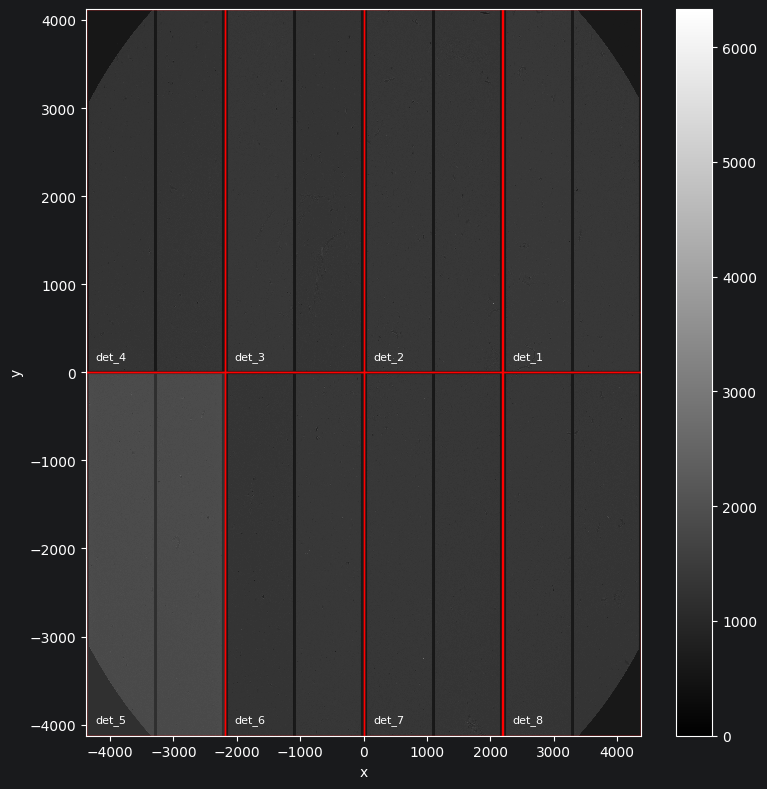

In [11]:
# quick_plot(flpair.data[0])
plot_focal_plane(flpair.data)

In [12]:
# Do bias sub
bias_sub = BiasSubtraction(quick=True)
after_bs = bias_sub.run(images=flpair.data, master_bias=mb_res.master_bias)

/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/si

,object,type,exptime,seqnum,obstime,bias_subtracted
0,<datamodels.focalplaneimage.FocalPlaneImage ob...,flat,0.032,0,2026-07-18T040300.129,True
1,<datamodels.focalplaneimage.FocalPlaneImage ob...,flat,0.032,1,2026-07-18T040427.627,True


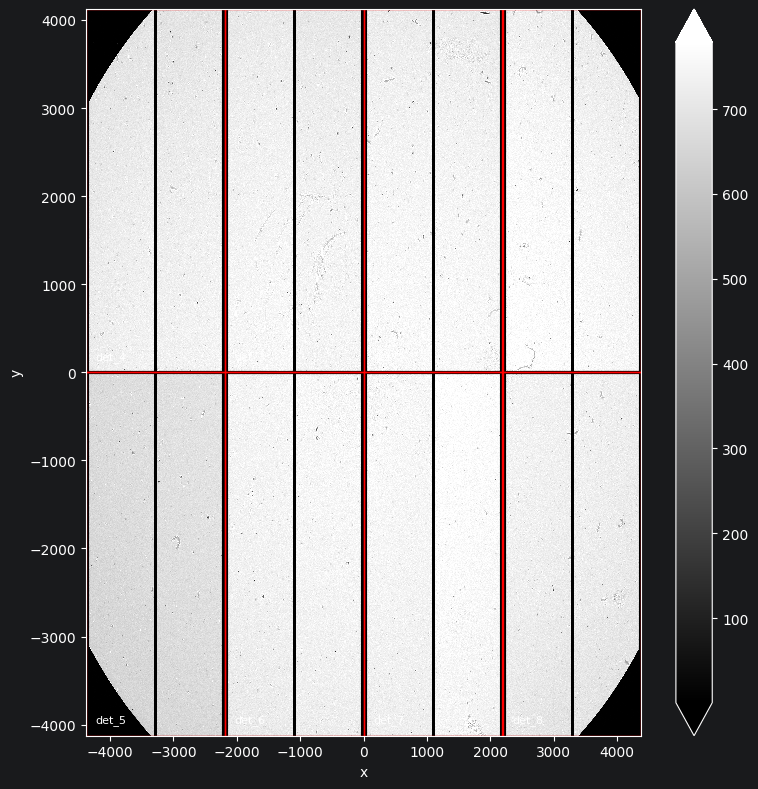

In [15]:
# quick_plot(after_bs.data[0])
plot_focal_plane(after_bs.data, zscale=True)

In [16]:
# Do overscan sub
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')
after_osub = oscan_sub.run(images=after_bs.data)

2026-07-24 21:05:13,897 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.


,object,type,exptime,seqnum,obstime,bias_subtracted,serial_overscan_subtracted
0,<datamodels.focalplaneimage.FocalPlaneImage ob...,flat,0.032,0,2026-07-18T040300.129,True,True
1,<datamodels.focalplaneimage.FocalPlaneImage ob...,flat,0.032,1,2026-07-18T040427.627,True,True


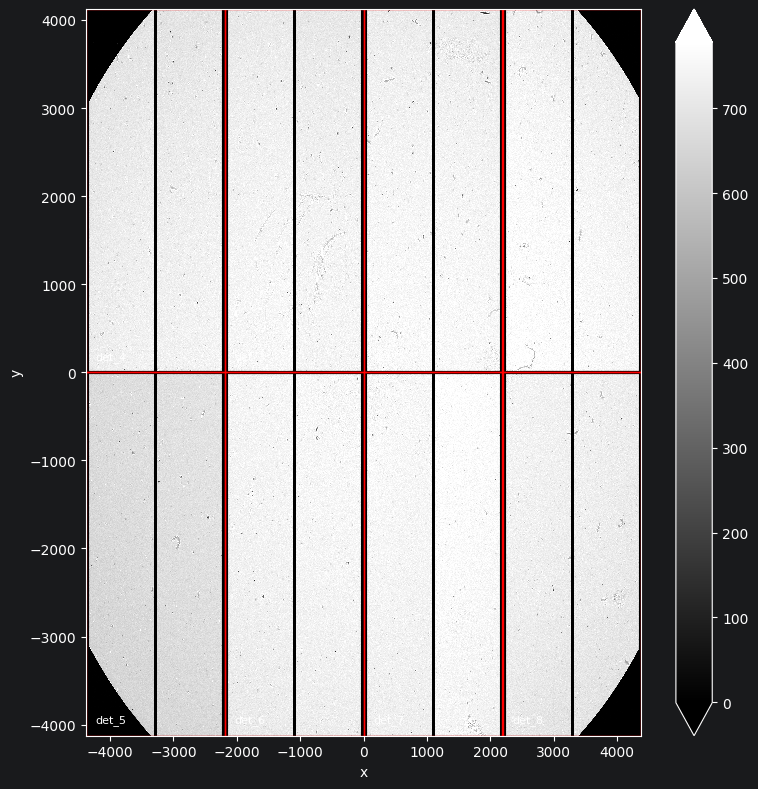

In [18]:
# quick_plot(after_osub.data[0])
plot_focal_plane(after_osub.data, zscale=True)

In [20]:
# Do sigma clip
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5}) # set n_jobs=1 to be able to debug in pycharm inside parallelized jobs
after_cr = cr_mask.run(images=deepcopy(after_osub.data))

2026-07-24 21:08:32,106 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.


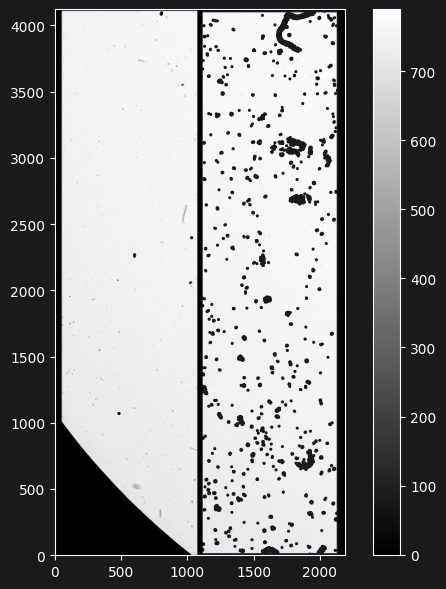

In [22]:
quick_plot(after_cr.data[0])
# plot_focal_plane(after_cr.data, zscale=True)  # TODO: Add masks to FocalPlaneImage?

In [13]:
# Do PTC
import eregion.tasks.ptc as ptc
importlib.reload(ptc)

ptc_task = ptc.PTC()
pres = ptc_task.run(images=after_cr.data)

2026-07-24 11:18:01,062 - PTC - INFO - Doing per output stats on #0 image of 2
2026-07-24 11:18:01,957 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:04,590 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:06,179 - PTC - INFO - Doing per output stats on #1 image of 2
2026-07-24 11:18:07,089 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:09,643 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:11,253 - PTC - INFO - Doing diff pair analysis on index 0 and 1
2026-07-24 11:18:16,727 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:22,703 - PTC - INFO - Calculating correlation coefficients
2026-07-24 11:18:24,258 - PTC - INFO - Processed 2 flats, upto exptime 0.032


In [2]:
pres.ptc_table

NameError: name 'pres' is not defined

In [15]:
# save to fits
pres.save(outpath)

In [16]:
# load from fits
pres = ptc.PTCResult.load(outpath)
pres.ptc_table

,n_masked,med,mean,std,mad,skew,kurt,skewtest,skewtestp,kurttest,...,oscan_skewtest,oscan_skewtestp,oscan_kurttest,oscan_kurttestp,PSD,dPSD,det_id,output,exptime,diff
0,1848,738.621574,661.050144,231.083954,28.067979,-2.460585,4.197890,-1245.264823,0.000000,631.972845,...,189.748651,0.000000,114.890690,0.0,"[[9357845.283001326, 149.92266048119475, 97.44...","[[19445.125209299385, 0.9512116845162345, 0.52...",det_1,E,0.032,False
1,364988,756.141266,755.522348,24.699788,24.568455,-0.102718,0.123388,-81.933045,0.000000,46.500595,...,183.936891,0.000000,110.134402,0.0,"[[9969966.26923877, 160.13580720534378, 103.10...","[[14685.168622735771, 1.0246600523476088, 0.54...",det_1,F,0.032,False
2,3124,738.621941,661.085434,231.037317,28.061266,-2.461287,4.201420,-1245.260605,0.000000,632.098311,...,189.239657,0.000000,114.555773,0.0,"[[9353143.756280692, 150.1300539315452, 97.911...","[[19447.31706664232, 0.9577972265131448, 0.521...",det_1,E,0.032,False
3,368080,756.122700,755.529328,24.719519,24.570508,-0.098285,0.131600,-78.382299,0.000000,49.388090,...,184.165143,0.000000,110.293851,0.0,"[[9949454.624108983, 160.4558033790253, 103.43...","[[14701.306281336247, 1.0272109865183494, 0.55...",det_1,F,0.032,False
4,32262,-0.016376,-0.003953,22.220257,20.276530,0.001243,0.356379,1.036634,0.299906,126.593101,...,-0.206104,0.836710,52.619609,0.0,"[[88.54448212674974, 80.49375682241664, 81.720...","[[0.5652107492103501, 0.34358709924747893, 0.3...",det_1,E,0.032,True
5,13025,-0.007584,-0.010100,24.024983,24.015505,0.002104,0.007179,1.758518,0.078659,2.990373,...,-2.247919,0.024581,60.457735,0.0,"[[82.82022216195308, 80.90786445426889, 81.449...","[[0.5327778756436191, 0.34811230746785937, 0.3...",det_1,F,0.032,True


### Everything together

In [17]:
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)
bias_sub = BiasSubtraction()
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5})
ptc_task = ptc.PTC()

count = 0
# Load flat images in batches (lazy mode)
for flpair in creator.lazy_run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*flat*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True):
    flpair = bias_sub.run(images=flpair.data, master_bias=mb_res.master_bias)
    flpair = oscan_sub.run(images=flpair.data)
    flpair = cr_mask.run(images=flpair.data)
    ptcres = ptc_task.run(images=flpair.data)

    if count==0:
        preproc_res = flpair
        ptc_res = ptcres
    else:
        preproc_res = preproc_res.combine(flpair)
        ptc_res = ptc_res.combine(ptcres)
    count+=1
    print('Pairs processed: ', count)
    if count>=1:
        break


2026-07-24 11:18:49,467 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:18:49,467 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:18:49,467 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:18:49,468 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-24 11:18:49,468 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-24 11:18:49,469 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-07-24 11:18:49,469 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-07-24 11:18:49,469 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*flat*.fits is a glob pattern
2026-07-24 11:18:49,469 

Pairs processed:  1


In [18]:
ptc_res.save(outpath)